In [1]:
import pandas as pd
import json

summary = pd.read_csv("./DarkBERT/topic_summary.csv")

darkbert_900_90 = summary[
    (summary["EmbeddingModel"] == "s2w-ai/DarkBERT") &
    (summary["Parameters"].astype(str) == "900_90")
].copy()

print(darkbert_900_90.shape)
darkbert_900_90.head()

(84, 5)


,EmbeddingModel,Parameters,Topic_id,LocalLLM_Topic,TopWords_JSON
0,s2w-ai/DarkBERT,900_90,0,member joined june,"[""golden member"", ""message reaction"", ""followi..."
1,s2w-ai/DarkBERT,900_90,1,kib files torrent mib zip txt,"[""torrent kib"", ""txt kib"", ""kib november"", ""tx..."
2,s2w-ai/DarkBERT,900_90,2,buyed product online,"[""buyed product"", ""product paypal"", ""product v..."
3,s2w-ai/DarkBERT,900_90,3,new search feature,"[""forum new"", ""browser forum"", ""new search"", ""..."
4,s2w-ai/DarkBERT,900_90,4,tor server support,"[""url server"", ""debian server"", ""server apache..."


In [2]:
def parse_topwords(x):
    try:
        words = json.loads(x)
        if isinstance(words, list):
            return ", ".join(words[:8])
    except Exception:
        pass
    return str(x)

darkbert_900_90["Example Keywords"] = darkbert_900_90["TopWords_JSON"].apply(parse_topwords)

topic_label_table = darkbert_900_90[[
    "Topic_id",
    "LocalLLM_Topic",
    "Example Keywords"
]].rename(columns={
    "Topic_id": "Topic ID",
    "LocalLLM_Topic": "Label"
})

topic_label_table.head(20)

,Topic ID,Label,Example Keywords
0,0,member joined june,"golden member, message reaction, following rea..."
1,1,kib files torrent mib zip txt,"torrent kib, txt kib, kib november, txt mib, z..."
2,2,buyed product online,"buyed product, product paypal, product visa, g..."
3,3,new search feature,"forum new, browser forum, new search, member p..."
4,4,tor server support,"url server, debian server, server apache, tor ..."
5,5,new search forum,"forum new, new search, search forum, javascrip..."
6,6,subagames database com,"com database, stresser database, subagames dat..."
7,7,online banking protection,"categorycarding statusonline, item category, u..."
8,8,world news politics -,"politics world, war problem, question answer, ..."
9,9,online money maker,"way make, make money, money money, online mone..."


In [3]:
import pandas as pd
import re
import json

INPUT_CSV = "./DarkBERT/topic_summary.csv"
OUTPUT_CSV = "./DarkBERT/darkbert_900_90_cleaned_labels.csv"

df = pd.read_csv(INPUT_CSV)

def clean_topic_label(label):
    if pd.isna(label):
        return ""

    s = str(label).replace("\n", " ").strip()

    # Keep content inside wrappers like:
    # (e.g. "Hacked Bank Accounts")
    # (e.e. "Naruto Discussion")
    m = re.fullmatch(r'\(\s*e\.[a-z]\.\s*["\'](.*?)["\']\s*\)', s, flags=re.IGNORECASE)
    if m:
        s = m.group(1).strip()

    # Remove common instruction prefixes but keep text after colon
    prefix_patterns = [
        r'^\s*Here is .*?:\s*',
        r'^\s*I am looking for:\s*',
        r'^\s*topic label for the given text:\s*',
        r'^\s*descriptive topic label:\s*',
        r'^\s*topic label:\s*',
    ]
    for p in prefix_patterns:
        s = re.sub(p, '', s, flags=re.IGNORECASE)

    # Re-check example wrappers after prefix removal
    m = re.fullmatch(r'\(\s*e\.[a-z]\.\s*["\'](.*?)["\']\s*\)', s, flags=re.IGNORECASE)
    if m:
        s = m.group(1).strip()

    # Remove placeholders like (4 words)
    if re.fullmatch(r'\(\s*\d+\s+words?\s*\)', s, flags=re.IGNORECASE):
        s = ""

    # Remove obvious leftover instruction text
    bad_starts = [
        "do not include",
        "return only",
        "only the topic",
        "for the given text",
    ]
    lower = s.lower().strip()
    if any(lower.startswith(x) for x in bad_starts):
        s = ""

    # Strip wrapping quotes and leftover quotes
    s = s.strip().strip('"').strip("'").strip()
    s = s.replace('"', '').replace("'", "")

    # Remove leading punctuation leftovers
    s = re.sub(r'^[\s:;,\-–—]+', '', s)

    # Collapse spaces
    s = re.sub(r'\s+', ' ', s).strip()

    return s

def parse_keywords(topwords_json, n=10):
    try:
        words = json.loads(topwords_json)
        if isinstance(words, list):
            return ", ".join(str(w).strip() for w in words[:n] if str(w).strip())
    except Exception:
        pass
    return str(topwords_json)

def fallback_from_topwords(topwords_json, n=3):
    try:
        words = json.loads(topwords_json)
        if isinstance(words, list) and words:
            return " / ".join(str(w).strip() for w in words[:n] if str(w).strip())
    except Exception:
        pass
    return ""

# Filter only DarkBERT 900_90
df = df[
    (df["EmbeddingModel"] == "s2w-ai/DarkBERT") &
    (df["Parameters"].astype(str) == "900_90")
].copy()

# Clean labels
df["Cleaned_Label"] = df["LocalLLM_Topic"].apply(clean_topic_label)

# Fallback if cleaned label becomes empty
empty_mask = df["Cleaned_Label"].fillna("").str.strip().eq("")
df.loc[empty_mask, "Cleaned_Label"] = df.loc[empty_mask, "TopWords_JSON"].apply(fallback_from_topwords)

# Parse keywords into readable form
df["Keywords"] = df["TopWords_JSON"].apply(parse_keywords)

# Keep only the useful columns
out_df = df[[
    "Topic_id",
    "LocalLLM_Topic",
    "Cleaned_Label",
    "Keywords"
]].rename(columns={
    "Topic_id": "Topic_ID",
    "LocalLLM_Topic": "Original_Label"
}).sort_values("Topic_ID").reset_index(drop=True)

# Save
out_df.to_csv(OUTPUT_CSV, index=False)

print("Saved file to:", OUTPUT_CSV)
display(out_df)

Saved file to: ./DarkBERT/darkbert_900_90_cleaned_labels.csv


,Topic_ID,Original_Label,Cleaned_Label,Keywords
0,0,member joined june,member joined june,"golden member, message reaction, following rea..."
1,1,kib files torrent mib zip txt,kib files torrent mib zip txt,"torrent kib, txt kib, kib november, txt mib, z..."
2,2,buyed product online,buyed product online,"buyed product, product paypal, product visa, g..."
3,3,new search feature,new search feature,"forum new, browser forum, new search, member p..."
4,4,tor server support,tor server support,"url server, debian server, server apache, tor ..."
...,...,...,...,...
79,79,digital service money,digital service money,"customer service, delivery category, service m..."
80,80,lapostermobile txt kib december,lapostermobile txt kib december,"december lapostermobile, txt kib, kib november..."
81,81,dream house maker,dream house maker,"dream create, kind image, golden member, influ..."
82,82,highest quality counterfeit money,highest quality counterfeit money,"money country, counterfeit money, quality coun..."


Saved full table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_final_topic_distribution_table.csv


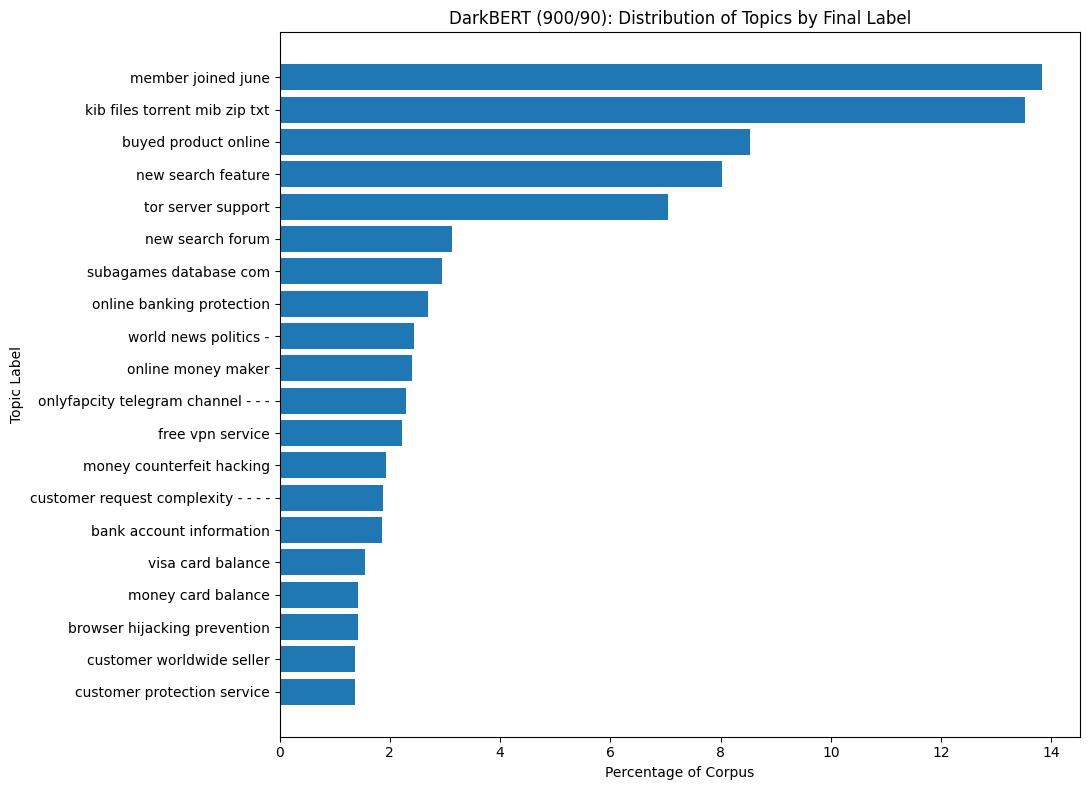

Saved figure to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_final_topic_distribution.png


,Topic,Cleaned_Label,Count,% of Corpus,Keywords
0,0,member joined june,903883,13.83,"golden member, message reaction, following rea..."
1,1,kib files torrent mib zip txt,884012,13.52,"torrent kib, txt kib, kib november, txt mib, z..."
2,2,buyed product online,558270,8.54,"buyed product, product paypal, product visa, g..."
3,3,new search feature,524089,8.02,"forum new, browser forum, new search, member p..."
4,4,tor server support,461151,7.06,"url server, debian server, server apache, tor ..."
...,...,...,...,...,...
79,79,digital service money,1605,0.02,"customer service, delivery category, service m..."
80,80,lapostermobile txt kib december,1547,0.02,"december lapostermobile, txt kib, kib november..."
81,81,dream house maker,1493,0.02,"dream create, kind image, golden member, influ..."
82,82,highest quality counterfeit money,1087,0.02,"money country, counterfeit money, quality coun..."



LaTeX table (top 20):

\begin{tabular}{rlrrl}
\toprule
Topic ID & Topic Label & Count & % of Corpus & Keywords \\
\midrule
0 & member joined june & 903883 & 13.83 & golden member, message reaction, following reaction, june message, buyer protection, infinity member, joined june, reaction like, member joined, content reply \\
1 & kib files torrent mib zip txt & 884012 & 13.52 & torrent kib, txt kib, kib november, txt mib, zip kib, q1s4z zip, torrent mib, kib december, mib november, kib february \\
2 & buyed product online & 558270 & 8.54 & buyed product, product paypal, product visa, gift card, card balance, buyed, western union, prepaid card, rated add, paypal transfer \\
3 & new search feature & 524089 & 8.02 & forum new, browser forum, new search, member profile, log register, post forum, search forum, disabled forum, forum feature, javascript browser \\
4 & tor server support & 461151 & 7.06 & url server, debian server, server apache, tor support, requested url, email address, ques

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for loading saved model with custom reducer
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X

# -------------------------
# Paths
# -------------------------
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/darkbert_900_90_cleaned_labels.csv")
FIG_PATH = Path("./DarkBERT/darkbert_final_topic_distribution.png")
TABLE_PATH = Path("./DarkBERT/darkbert_final_topic_distribution_table.csv")

# -------------------------
# Load model + topic counts
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topic_info = topic_model.get_topic_info().copy()

# keep real topics only
topic_info = topic_info[topic_info["Topic"] != -1].copy()

# -------------------------
# Load merged labels file
# -------------------------
labels_df = pd.read_csv(LABELS_PATH)

# required columns in merged file
required_cols = {"Topic_ID", "Cleaned_Label", "Keywords"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(f"Missing columns in merged labels file: {missing}")

# Topic_ID should match BERTopic topic numbers
labels_df = labels_df.rename(columns={"Topic_ID": "Topic"})

# make sure Topic is numeric
labels_df["Topic"] = pd.to_numeric(labels_df["Topic"], errors="coerce")
labels_df = labels_df.dropna(subset=["Topic"]).copy()
labels_df["Topic"] = labels_df["Topic"].astype(int)

# -------------------------
# Merge counts with cleaned labels
# -------------------------
merged = topic_info.merge(
    labels_df[["Topic", "Cleaned_Label", "Keywords"]],
    on="Topic",
    how="left"
)

merged["Cleaned_Label"] = merged["Cleaned_Label"].fillna("Unlabeled Topic")
merged["Keywords"] = merged["Keywords"].fillna("")

# Percentage of corpus
merged["% of Corpus"] = 100 * merged["Count"] / merged["Count"].sum()

# sort descending for table
merged = merged.sort_values("% of Corpus", ascending=False).reset_index(drop=True)

# -------------------------
# Save full table
# -------------------------
table_df = merged[["Topic", "Cleaned_Label", "Count", "% of Corpus", "Keywords"]].copy()
table_df["% of Corpus"] = table_df["% of Corpus"].round(2)
table_df.to_csv(TABLE_PATH, index=False)

print(f"Saved full table to: {TABLE_PATH.resolve()}")

# -------------------------
# Plot top N topics
# -------------------------
TOP_N = 20
plot_df = merged.head(TOP_N).sort_values("% of Corpus", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df["Cleaned_Label"], plot_df["% of Corpus"])
plt.xlabel("Percentage of Corpus")
plt.ylabel("Topic Label")
plt.title("DarkBERT (900/90): Distribution of Topics by Final Label")
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {FIG_PATH.resolve()}")

# -------------------------
# Display table for paper
# -------------------------
display(table_df)

print("\nLaTeX table (top 20):\n")
print(
    table_df.head(20).rename(columns={
        "Topic": "Topic ID",
        "Cleaned_Label": "Topic Label"
    }).to_latex(index=False, float_format="%.2f")
)

In [12]:
import csv
import pandas as pd
from pathlib import Path

LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/darkbert_merged_by_final.csv")

rows = []
with open(LABELS_PATH, "r", encoding="utf-8", newline="") as f:
    header = next(f).strip().split(",")

    for line in f:
        line = line.rstrip("\r\n")

        # remove outer row quotes if present
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]

        # parse again as CSV
        parsed = next(csv.reader([line]))

        rows.append(parsed)

# inspect lengths
for i, r in enumerate(rows[:10]):
    print(i, len(r), r)

0 16 ['0', 'Do not include any words that are not descriptive of the topic.', 'Shop/Forum Membership', 'golden member', ' message reaction', ' following reaction', ' june message', ' buyer protection', ' infinity member', ' joined june', ' reaction like', ' member joined', ' content reply""', '0', 'Forum Reputation and Member Interaction', 'Forum Reputation']
1 96 ['1', ' 31', ' 32', ' 38', ' 45', ' 52', ' 56', ' 57', ' 60', ' 62', ' 65', ' 70', ' 80', '(e.g. """"Torrents and File Sizes"""") | Do not include any extraneous text. | (e.g. """"Torrents and Zip Files"""") | (e.g. """"Torrents and Files"""") | (e.g. """"Torrents and Directories"""") | (e.g. """"Computer Virus Removal"""") | (e.g. """"Bitcoin Prices"""") | (e.g. """"Torrent Files"""") | Mobile Phone Torrents""', 'Torrents and File Sizes | File Size Formats | Torrents and Zip Files | Torrents and Files | Torrents and Directories | torrent kib / kib november / txt kib | Computer Virus Removal | Bitcoin Prices | Torrent Files |

Detected delimiter: ';'
Parsed grouped rows: 84
Unique topic IDs parsed from CSV: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]
Unique topic IDs in BERTopic model: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]


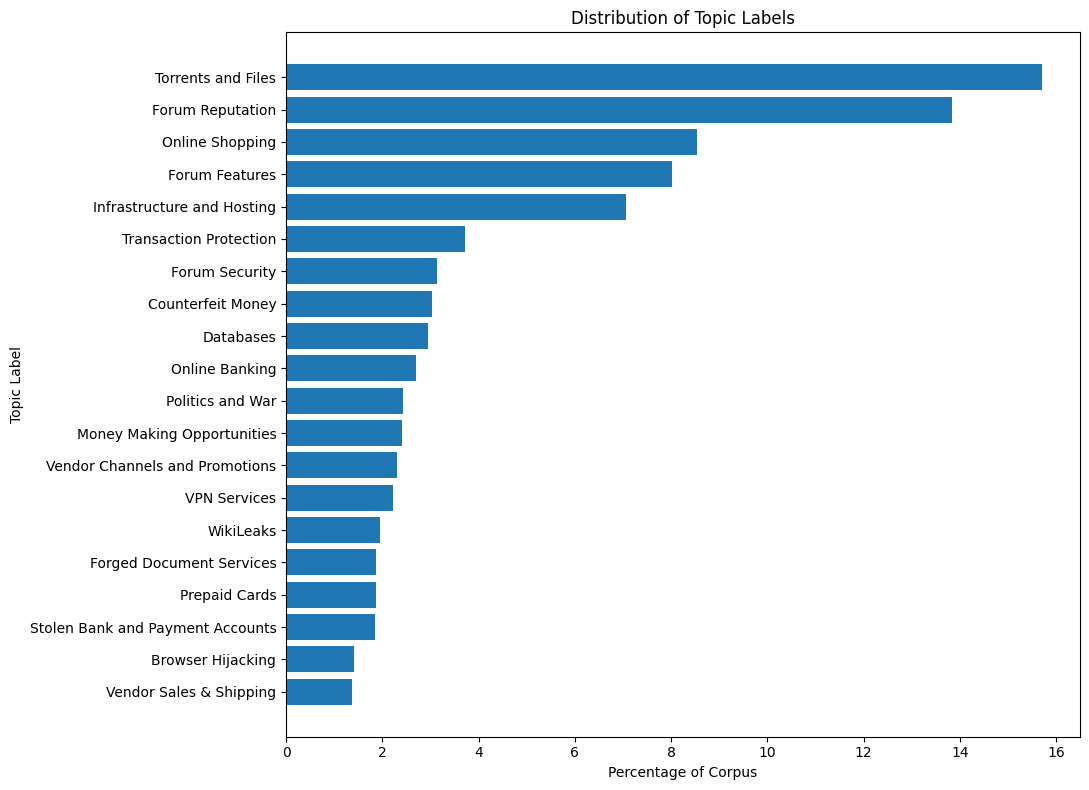

,Final,Count,% of Corpus,Keywords
0,Torrents and Files,1026851,15.71,"torrent kib, txt kib, kib november, txt mib, z..."
1,Forum Reputation,903883,13.83,"golden member, message reaction, following rea..."
2,Online Shopping,558270,8.54,"buyed product, product paypal, product visa, g..."
3,Forum Features,524089,8.02,"forum new, browser forum, new search, member p..."
4,Infrastructure and Hosting,461151,7.06,"url server, debian server, server apache, tor ..."
5,Transaction Protection,243077,3.72,"paypal true, buyer protection, parcel guide, p..."
6,Forum Security,204509,3.13,"forum new, new search, search forum, javascrip..."
7,Counterfeit Money,197892,3.03,"electronics porn, countersurveillance btc, ban..."
8,Databases,192833,2.95,"com database, stresser database, subagames dat..."
9,Online Banking,175989,2.69,"categorycarding statusonline, item category, u..."


\begin{tabular}{lrrl}
\toprule
Topic Label & Count & % of Corpus & Keywords \\
\midrule
Torrents and Files & 1026851 & 15.71 & torrent kib, txt kib, kib november, txt mib, zip kib, q1s4z zip, torrent mib, kib december, mib november, kib february, pj8t6 rar, lcpa0 rar, ldsu2 rar, z1bc6 zip, pwf25 rar, q0bdx zip, w1kfi zip, 2wobm zip, 2doz9 zip, january january, february february, mib january, mib february, 7aj6k zip, 8cza3 file, com n3e1b, rv3z3 zip, directory rv3z3, com 2h0gq, n3e1b rar, crypto paypal, je0mt rar, roteritaly com, index roteritaly, discord server, directory je0mt, refresh expired, february lh0mk, lh0mk rar, mib lh0mk, july lh0mk, directory lh0mk, march wnrllc, od2dw rar, index wnrllc, april l0cdb, january l0cdb, february kiyxc, directory kiyxc, february mtkuy, august kiyxc, 7z_file_tree txt, april btc, 7z_file_tree, january btc, february btc, 2a9ii zip, january 0j5r6, march 0j5r6, february 0j5r6, april 0j5r6, directory 0j5r6, 0j5r6 zip, com 0j5r6, mib 0j5r6, q6f47 zip, f

In [30]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path


class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")
FIG_PATH = Path("./DarkBERT/darkbert_final_topic_distribution.pdf")
TABLE_PATH = Path("./DarkBERT/darkbert_final_topic_distribution_table.csv")


def detect_delimiter(path: Path) -> str:
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        first_line = f.readline()
    if first_line.count(";") > first_line.count(","):
        return ";"
    return ","


def load_grouped_labels_csv(path: Path) -> pd.DataFrame:
    rows = []
    delimiter = detect_delimiter(path)
    print(f"Detected delimiter: {repr(delimiter)}")

    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f, delimiter=delimiter)

        fieldnames = [name.strip() for name in (reader.fieldnames or [])]
        expected = {"Topic_ID", "Original_Label", "Cleaned_Label", "Keywords", "Check", "Correction", "Final"}
        missing = expected - set(fieldnames)
        if missing:
            raise ValueError(
                f"Missing columns in merged labels file: {missing}\n"
                f"Detected fieldnames: {fieldnames}"
            )

        for raw_row in reader:
            row = {(k.strip() if k else k): v for k, v in raw_row.items()}

            topic_id_raw = (row.get("Topic_ID") or "").strip()
            final_raw = (row.get("Final") or "").strip()
            keywords_raw = (row.get("Keywords") or "").strip()

            if not topic_id_raw:
                continue

            topic_ids = [x.strip() for x in topic_id_raw.split(",") if x.strip()]

            for tid in topic_ids:
                if tid.isdigit():
                    rows.append({
                        "Topic": int(tid),
                        "Final": final_raw,
                        "Keywords": keywords_raw,
                        "Grouped_Topic_ID": topic_id_raw,
                    })
                else:
                    print(f"Warning: could not parse Topic_ID token '{tid}' from grouped field '{topic_id_raw}'")

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No topic rows were parsed from the grouped CSV.")

    return df


# Better PDF font embedding
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

topic_model = BERTopic.load(MODEL_PATH)
topic_info = topic_model.get_topic_info().copy()
topic_info = topic_info[topic_info["Topic"] != -1].copy()

labels_df = load_grouped_labels_csv(LABELS_PATH)

print("Parsed grouped rows:", len(labels_df))
print("Unique topic IDs parsed from CSV:", sorted(labels_df["Topic"].unique().tolist()))
print("Unique topic IDs in BERTopic model:", sorted(topic_info["Topic"].unique().tolist()))

missing_topics = sorted(set(topic_info["Topic"]) - set(labels_df["Topic"]))
if missing_topics:
    raise ValueError(
        "These BERTopic topics are still missing after robust CSV parsing: "
        f"{missing_topics}"
    )

merged = topic_info.merge(
    labels_df[["Topic", "Final", "Keywords"]],
    on="Topic",
    how="inner"
)

final_df = (
    merged.groupby("Final", as_index=False)
    .agg({
        "Count": "sum",
        "Keywords": lambda x: " | ".join(
            sorted(set(k for k in x if pd.notna(k) and str(k).strip()))
        )
    })
)

final_df["% of Corpus"] = 100 * final_df["Count"] / final_df["Count"].sum()
final_df = final_df.sort_values("% of Corpus", ascending=False).reset_index(drop=True)

table_df = final_df[["Final", "Count", "% of Corpus", "Keywords"]].copy()
table_df["% of Corpus"] = table_df["% of Corpus"].round(2)

# Save output table with semicolon delimiter
table_df.to_csv(TABLE_PATH, sep=";", index=False, encoding="utf-8-sig")

TOP_N = 20
plot_df = table_df.head(TOP_N).sort_values("% of Corpus", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df["Final"], plot_df["% of Corpus"])
plt.xlabel("Percentage of Corpus")
plt.ylabel("Topic Label")
plt.title("Distribution of Topic Labels")
plt.tight_layout()
plt.savefig(FIG_PATH, bbox_inches="tight")
plt.show()

try:
    display(table_df)
except NameError:
    print(table_df.to_string(index=False))

print(
    table_df.head(20).rename(columns={"Final": "Topic Label"}).to_latex(
        index=False, float_format="%.2f"
    )
)

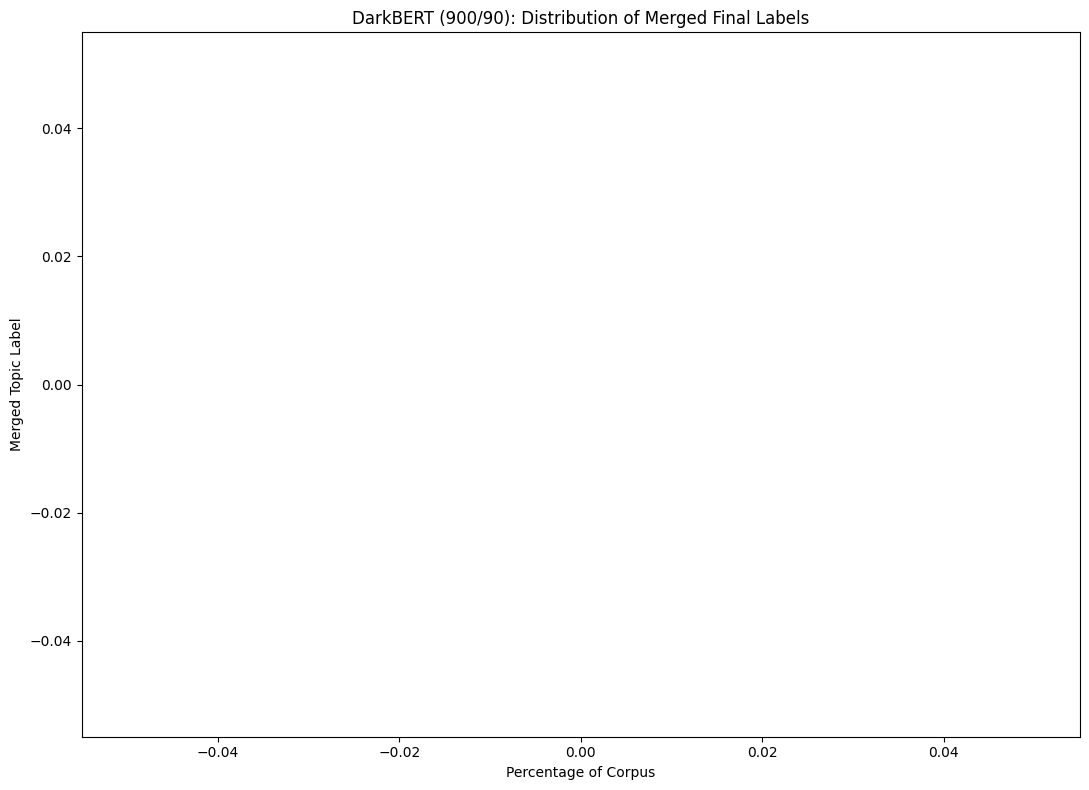

,Final,Count,% of Corpus,Keywords


\begin{tabular}{rrrr}
\toprule
Topic Label & Count & % of Corpus & Keywords \\
\midrule
\bottomrule
\end{tabular}



In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path

class IdentityReducer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def fit_transform(self, X, y=None):
        return X

MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/darkbert_merged_by_final.csv")
FIG_PATH = Path("./DarkBERT/darkbert_final_topic_distribution.png")
TABLE_PATH = Path("./DarkBERT/darkbert_final_topic_distribution_table.csv")

topic_model = BERTopic.load(MODEL_PATH)
topic_info = topic_model.get_topic_info().copy()
topic_info = topic_info[topic_info["Topic"] != -1].copy()

labels_df = pd.read_csv(LABELS_PATH)

required_cols = {"Topic_ID", "Final", "Keywords"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(f"Missing columns in merged labels file: {missing}")

labels_df = labels_df.rename(columns={"Topic_ID": "Topic"})
labels_df["Topic"] = pd.to_numeric(labels_df["Topic"], errors="coerce")
labels_df = labels_df.dropna(subset=["Topic"]).copy()
labels_df["Topic"] = labels_df["Topic"].astype(int)

merged = topic_info.merge(
    labels_df[["Topic", "Final", "Keywords"]],
    on="Topic",
    how="inner"   # only keep topics that actually exist in labels file
)

# combine counts by merged final label
final_df = (
    merged.groupby("Final", as_index=False)
    .agg({
        "Count": "sum",
        "Keywords": lambda x: " | ".join(sorted(set(k for k in x if pd.notna(k) and str(k).strip())))
    })
)

final_df["% of Corpus"] = 100 * final_df["Count"] / final_df["Count"].sum()
final_df = final_df.sort_values("% of Corpus", ascending=False).reset_index(drop=True)

table_df = final_df[["Final", "Count", "% of Corpus", "Keywords"]].copy()
table_df["% of Corpus"] = table_df["% of Corpus"].round(2)
table_df.to_csv(TABLE_PATH, index=False)

TOP_N = 20
plot_df = table_df.head(TOP_N).sort_values("% of Corpus", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df["Final"], plot_df["% of Corpus"])
plt.xlabel("Percentage of Corpus")
plt.ylabel("Merged Topic Label")
plt.title("DarkBERT (900/90): Distribution of Merged Final Labels")
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

display(table_df)

print(
    table_df.head(20).rename(columns={"Final": "Topic Label"}).to_latex(
        index=False, float_format="%.2f"
    )
)